In [1]:
# Factory-to-Customer Shipping Route Efficiency Analysis for Nassau Candy Distributor

In [2]:
# Import required libraries
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go

In [3]:
# Load data
df = pd.read_csv('Nassau Candy Distributor.csv')

In [4]:
# Factory locations
FACTORIES = {
    "Lot's O' Nuts":      {"lat": 32.881893, "lon": -111.768036},
    "Wicked Choccy's":    {"lat": 32.076176, "lon": -81.088371},
    "Sugar Shack":        {"lat": 48.11914,  "lon": -96.18115},
    "Secret Factory":     {"lat": 41.446333, "lon": -90.565487},
    "The Other Factory":  {"lat": 35.1175,   "lon": -89.971107},
}

# Product to factory mapping
PRODUCT_FACTORY = {
    "Wonka Bar - Nutty Crunch Surprise":   "Lot's O' Nuts",
    "Wonka Bar - Fudge Mallows":           "Lot's O' Nuts",
    "Wonka Bar -Scrumdiddlyumptious":      "Lot's O' Nuts",
    "Wonka Bar - Milk Chocolate":          "Wicked Choccy's",
    "Wonka Bar - Triple Dazzle Caramel":   "Wicked Choccy's",
    "Laffy Taffy":                         "Sugar Shack",
    "SweeTARTS":                           "Sugar Shack",
    "Nerds":                               "Sugar Shack",
    "Fun Dip":                             "Sugar Shack",
    "Fizzy Lifting Drinks":                "Sugar Shack",
    "Everlasting Gobstopper":              "Secret Factory",
    "Lickable Wallpaper":                  "Secret Factory",
    "Wonka Gum":                           "Secret Factory",
    "Hair Toffee":                         "The Other Factory",
    "Kazookles":                           "The Other Factory",
}

In [5]:
# Show the first 5 values
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost
0,1,US-2021-103800-CHO-MIL-31000,03-01-2024,30-06-2026,Standard Class,103800,United States,Houston,Texas,77095,Chocolate,Interior,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28
1,2,US-2021-112326-CHO-TRI-54000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60
2,3,US-2021-112326-CHO-NUT-13000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,10.47,3,7.47,3.00
3,4,US-2021-112326-CHO-SCR-58000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,10.80,3,7.50,3.30
4,5,US-2021-141817-CHO-TRI-54000,05-01-2024,05-07-2026,Standard Class,141817,United States,Philadelphia,Pennsylvania,19143,Chocolate,Atlantic,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,11.25,3,7.35,3.90


In [6]:
# Get info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          10194 non-null  int64  
 1   Order ID        10194 non-null  object 
 2   Order Date      10194 non-null  object 
 3   Ship Date       10194 non-null  object 
 4   Ship Mode       10194 non-null  object 
 5   Customer ID     10194 non-null  int64  
 6   Country/Region  10194 non-null  object 
 7   City            10194 non-null  object 
 8   State/Province  10194 non-null  object 
 9   Postal Code     10194 non-null  object 
 10  Division        10194 non-null  object 
 11  Region          10194 non-null  object 
 12  Product ID      10194 non-null  object 
 13  Product Name    10194 non-null  object 
 14  Sales           10194 non-null  float64
 15  Units           10194 non-null  int64  
 16  Gross Profit    10194 non-null  float64
 17  Cost            10194 non-null 

In [7]:
# Validate date format

In [8]:
# YYYY-MM-DD (standard format) Order Date
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d-%m-%Y', errors='coerce')

In [9]:
# YYYY-MM-DD (standard format) Ship Date
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='%d-%m-%Y', errors='coerce')

In [10]:
# Identify Invalid Dates
invalid_dates = df[df['Order Date'].isnull()]

print("Invalid rows:")
print(invalid_dates)

Invalid rows:
Empty DataFrame
Columns: [Row ID, Order ID, Order Date, Ship Date, Ship Mode, Customer ID, Country/Region, City, State/Province, Postal Code, Division, Region, Product ID, Product Name, Sales, Units, Gross Profit, Cost]
Index: []


In [11]:
# Count invalid entries
print("Total invalid dates:", df['Order Date'].isnull().sum())

Total invalid dates: 0


In [12]:
# Drop invalid entries
df = df.dropna(subset=['Order Date'])

In [13]:
# Calculate Lead Time
df['Lead Time'] = (df['Ship Date'] - df['Order Date']).dt.days
df = df[df['Lead Time'] >= 0].copy()

# Add Factory and Route
df['Factory'] = df['Product Name'].map(PRODUCT_FACTORY)
df['Route'] = df['Factory'] + ' → ' + df['Country/Region'] + ' - ' + df['State/Province']
df['Month'] = df['Order Date'].dt.to_period('M').astype(str)

# Clean text columns
for col in ['Country/Region', 'State/Province', 'City']:
    df[col] = df[col].str.strip().str.title()

# Verify data
print("Data shape:", df.shape)
print("Lead Time stats:")
print(df['Lead Time'].describe())

Data shape: (10194, 22)
Lead Time stats:
count    10194.000000
mean      1320.841868
std        262.444892
min        904.000000
25%       1271.000000
50%       1274.000000
75%       1638.000000
max       1642.000000
Name: Lead Time, dtype: float64


In [14]:
# Extract features
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Day'] = df['Order Date'].dt.day

In [15]:
# Calculate Lead Time
df['Shipping Lead Time'] = (df['Ship Date'] - df['Order Date']).dt.days

In [16]:
# Verify output
print(df[['Order Date', 'Ship Date', 'Shipping Lead Time']].head())

  Order Date  Ship Date  Shipping Lead Time
0 2024-01-03 2026-06-30                 909
1 2024-01-04 2026-07-01                 909
2 2024-01-04 2026-07-01                 909
3 2024-01-04 2026-07-01                 909
4 2024-01-05 2026-07-05                 912


In [17]:
# Validate lead time
df = df[(df['Shipping Lead Time'].notnull()) & (df['Shipping Lead Time'] >= 0)]

In [18]:
# Verify it
print(df['Shipping Lead Time'].isnull().sum())

0


In [19]:
# Check missing shipment records
missing_ship = df[df['Ship Date'].isnull()]

print("Missing shipment records:", missing_ship.shape[0])
missing_ship.head()

Missing shipment records: 0


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,...,Units,Gross Profit,Cost,Lead Time,Factory,Route,Month,Year,Day,Shipping Lead Time


In [20]:
# Cleane data columns
for col in ['Country/Region', 'State/Province', 'City']:
    df[col] = df[col].str.strip()      # remove spaces
    df[col] = df[col].str.title()     # standard case

In [21]:
# Clean unrealistic values
df = df[df['Shipping Lead Time'] >= 0]

In [22]:
# Check for the null values
print(df['Shipping Lead Time'].isnull().sum())

0


In [23]:
# Quick sanity check
print("Average Lead Time:", df['Shipping Lead Time'].mean())
print("Max Lead Time:", df['Shipping Lead Time'].max())

Average Lead Time: 1320.8418677653522
Max Lead Time: 1642


In [24]:
# Create Routes Factory -> Region
df['Route_Region'] = 'Factory → ' + df['Country/Region'] + ' - ' + df['Region']

In [25]:
# Create Routes Factory -> State
df['Route_State'] = 'Factory → ' + df['Country/Region'] + ' - ' + df['State/Province']

In [26]:
# Verify it
df[['Route_Region', 'Route_State']].head()

,Route_Region,Route_State
0,Factory → United States - Interior,Factory → United States - Texas
1,Factory → United States - Interior,Factory → United States - Illinois
2,Factory → United States - Interior,Factory → United States - Illinois
3,Factory → United States - Interior,Factory → United States - Illinois
4,Factory → United States - Atlantic,Factory → United States - Pennsylvania


In [27]:
# Check available modes
df['Ship Mode'].unique()

array(['Standard Class', 'First Class', 'Second Class', 'Same Day'],
      dtype=object)

In [28]:
# Group by ship mode
df.groupby('Ship Mode').size()

Ship Mode
First Class       1548
Same Day           547
Second Class      1979
Standard Class    6120
dtype: int64

In [29]:
df['Ship Mode'].value_counts()

Ship Mode
Standard Class    6120
Second Class      1979
First Class       1548
Same Day           547
Name: count, dtype: int64

In [30]:
# Aggrigation by route Region

route_region_summary = df.groupby('Route_Region').agg(
    Total_Shipments=('Route_Region', 'count'),
    Avg_Lead_Time=('Shipping Lead Time', 'mean'),
    Lead_Time_Variability=('Shipping Lead Time', 'std')
).reset_index()

In [31]:
# Aggrigation by route state

route_state_summary = df.groupby('Route_State').agg(
    Total_Shipments=('Route_State', 'count'),
    Avg_Lead_Time=('Shipping Lead Time', 'mean'),
    Lead_Time_Variability=('Shipping Lead Time', 'std')
).reset_index()

In [32]:
route_region_summary.head()

,Route_Region,Total_Shipments,Avg_Lead_Time,Lead_Time_Variability
0,Factory → Canada - Atlantic,138,1275.992754,291.093195
1,Factory → Canada - Interior,12,1455.333333,191.139803
2,Factory → Canada - Pacific,50,1288.540000,295.004131
3,Factory → United States - Atlantic,2848,1325.010534,254.588321
4,Factory → United States - Gulf,1620,1311.374691,264.727855


In [33]:
route_state_summary.head()

,Route_State,Total_Shipments,Avg_Lead_Time,Lead_Time_Variability
0,Factory → Canada - Alberta,26,1274.076923,292.400673
1,Factory → Canada - British Columbia,22,1290.318182,308.425091
2,Factory → Canada - Manitoba,12,1455.333333,191.139803
3,Factory → Canada - New Brunswick,8,1273.250000,276.292159
4,Factory → Canada - Newfoundland And Labrador,6,1216.166667,357.447292


In [34]:
# Key Performance Indicators
total_shipments = len(df)
avg_lead = df['Shipping Lead Time'].mean()
median_lead = df['Shipping Lead Time'].median()
delay_threshold = 7  # example
delayed = len(df[df['Shipping Lead Time'] > delay_threshold])
delay_pct = delayed / total_shipments * 100
total_sales = df['Sales'].sum()
total_profit = df['Gross Profit'].sum()
efficiency_score = 100 - (avg_lead / df['Shipping Lead Time'].max() * 100) if df['Shipping Lead Time'].max() > 0 else 100

print("=== Key Performance Indicators ===")
print(f"Total Shipments: {total_shipments:,}")
print(f"Average Lead Time: {avg_lead:.1f} days")
print(f"Median Lead Time: {median_lead:.1f} days")
print(f"Delayed Shipments (>{delay_threshold}d): {delayed:,} ({delay_pct:.1f}%)")
print(f"Total Sales: ${total_sales:,.0f}")
print(f"Total Gross Profit: ${total_profit:,.0f}")
print(f"Profit Margin: {(total_profit / total_sales * 100):.1f}%" if total_sales > 0 else "N/A")
print(f"Efficiency Score: {efficiency_score:.1f}%")

=== Key Performance Indicators ===
Total Shipments: 10,194
Average Lead Time: 1320.8 days
Median Lead Time: 1274.0 days
Delayed Shipments (>7d): 10,194 (100.0%)
Total Sales: $141,784
Total Gross Profit: $93,443
Profit Margin: 65.9%
Efficiency Score: 19.6%


In [35]:
# Rank by Region

route_region_ranked = route_region_summary.sort_values(by='Avg_Lead_Time')

In [36]:
# Rank by State

route_state_ranked = route_state_summary.sort_values(by='Avg_Lead_Time')

In [37]:
# Top 10 fastest route
top_10_routes = route_state_ranked.head(10)

In [38]:
# Bottom 10 slowest
bottom_10_routes = route_state_ranked.tail(10)

In [39]:
top_10_routes

,Route_State,Total_Shipments,Avg_Lead_Time,Lead_Time_Variability
27,Factory → United States - Maine,8,1137.125000,189.733977
4,Factory → Canada - Newfoundland And Labrador,6,1216.166667,357.447292
36,Factory → United States - Nevada,39,1226.794872,239.772390
54,Factory → United States - Virginia,224,1229.125000,256.420396
6,Factory → Canada - Ontario,58,1247.465517,272.269939
52,Factory → United States - Utah,53,1253.000000,289.780554
48,Factory → United States - South Carolina,42,1255.428571,241.749835
26,Factory → United States - Louisiana,42,1263.785714,306.777550
32,Factory → United States - Mississippi,53,1266.566038,263.148869
45,Factory → United States - Oregon,124,1267.709677,259.367642


In [40]:
bottom_10_routes

,Route_State,Total_Shipments,Avg_Lead_Time,Lead_Time_Variability
50,Factory → United States - Tennessee,183,1391.486339,248.201971
49,Factory → United States - South Dakota,12,1395.916667,360.350955
7,Factory → Canada - Prince Edward Island,10,1420.300000,255.814190
53,Factory → United States - Vermont,11,1438.909091,190.999714
39,Factory → United States - New Mexico,37,1441.837838,267.198066
23,Factory → United States - Iowa,30,1443.900000,229.801466
2,Factory → Canada - Manitoba,12,1455.333333,191.139803
9,Factory → Canada - Saskatchewan,2,1457.000000,258.801082
42,Factory → United States - North Dakota,7,1637.857143,1.463850
56,Factory → United States - West Virginia,4,1638.000000,2.000000


In [41]:
# Compare across ship modes

ship_mode_comparison = df.groupby('Ship Mode').agg(
    Avg_Lead_Time=('Shipping Lead Time', 'mean'),
    Total_Shipments=('Ship Mode', 'count')
).reset_index()

In [42]:
ship_mode_comparison

,Ship Mode,Avg_Lead_Time,Total_Shipments
0,First Class,1338.275840,1548
1,Same Day,1333.442413,547
2,Second Class,1323.845376,1979
3,Standard Class,1314.334641,6120


In [43]:
# High average lead time

avg_lead_time = df.groupby('State/Province')['Shipping Lead Time'].mean().sort_values(ascending=False)

avg_lead_time.head(10)

State/Province
West Virginia           1638.000000
North Dakota            1637.857143
Saskatchewan            1457.000000
Manitoba                1455.333333
Iowa                    1443.900000
New Mexico              1441.837838
Vermont                 1438.909091
Prince Edward Island    1420.300000
South Dakota            1395.916667
Tennessee               1391.486339
Name: Shipping Lead Time, dtype: float64

In [44]:
# High volume + poor performance

# Shipment volume
volume = df.groupby('State/Province').size()

# Avg lead time (reuse)
performance = df.groupby('State/Province')['Shipping Lead Time'].mean()

# Combine both
region_perf = pd.DataFrame({
    'Volume': volume,
    'Avg_Lead_Time': performance
})

# Sort for bottleneck detection
region_perf = region_perf.sort_values(by=['Volume', 'Avg_Lead_Time'], ascending=False)

region_perf.head(10)

,Volume,Avg_Lead_Time
State/Province,,
California,2001,1318.427286
New York,1128,1324.493794
Texas,985,1310.305584
Pennsylvania,587,1324.199319
Washington,506,1360.662055
Illinois,492,1323.150407
Ohio,469,1325.733475
Florida,383,1311.396867
Michigan,255,1300.560784


In [45]:
# Congation-Prone Region

# Define delay threshold (example: >5 days)
delay_threshold = 5

# Delay flag
df['Delayed'] = df['Shipping Lead Time'] > delay_threshold

# Aggregation
congestion = df.groupby('State/Province').agg({
    'Shipping Lead Time': ['mean', 'std'],
    'Delayed': 'mean'
})

# Flatten columns
congestion.columns = ['Avg_Lead_Time', 'Std_Dev', 'Delay_Frequency']

# Sort by delay frequency
congestion = congestion.sort_values(by='Delay_Frequency', ascending=False)

congestion.head(10)

,Avg_Lead_Time,Std_Dev,Delay_Frequency
State/Province,,,
Alabama,1291.278689,253.475320,1.0
Alberta,1274.076923,292.400673,1.0
Arizona,1309.214286,263.392440,1.0
Arkansas,1285.733333,284.746266,1.0
British Columbia,1290.318182,308.425091,1.0
California,1318.427286,264.392878,1.0
Colorado,1337.186813,249.676959,1.0
Connecticut,1357.548780,271.682874,1.0
Delaware,1269.750000,233.930669,1.0


In [46]:
# Average Lead Time by Ship Mode
ship_eff = df.groupby('Ship Mode')['Shipping Lead Time'].mean().sort_values()

ship_eff

Ship Mode
Standard Class    1314.334641
Second Class      1323.845376
Same Day          1333.442413
First Class       1338.275840
Name: Shipping Lead Time, dtype: float64

In [47]:
# Extended

ship_mode_perf = df.groupby('Ship Mode').agg({
    'Shipping Lead Time': ['mean', 'std'],
    'Order Date': 'count'
})

ship_mode_perf.columns = ['Avg_Lead_Time', 'Std_Dev', 'Volume']

ship_mode_perf.sort_values(by='Avg_Lead_Time')

,Avg_Lead_Time,Std_Dev,Volume
Ship Mode,,,
Standard Class,1314.334641,262.400116,6120
Second Class,1323.845376,261.813569,1979
Same Day,1333.442413,253.813374,547
First Class,1338.275840,265.632140,1548


In [48]:
# Division Analysis
division_analysis = df.groupby('Division').agg({
    'Shipping Lead Time': ['mean', 'std', 'count'],
    'Sales': 'sum',
    'Gross Profit': 'sum'
})
division_analysis.columns = ['Avg_Lead_Time', 'Std_Dev', 'Shipments', 'Total_Sales', 'Total_Profit']
division_analysis['Delay_Rate'] = df.assign(Delayed=df['Shipping Lead Time'] > delay_threshold).groupby('Division')['Delayed'].mean() * 100
division_analysis = division_analysis.round(2)

print("=== Division Analysis ===")
print(division_analysis)

=== Division Analysis ===
           Avg_Lead_Time  Std_Dev  Shipments  Total_Sales  Total_Profit  \
Division                                                                  
Chocolate        1321.17   261.85       9844    131692.90      88824.62   
Other            1306.03   281.66        310      9663.25       4333.45   
Sugar            1355.65   254.87         40       427.48        284.73   

           Delay_Rate  
Division               
Chocolate       100.0  
Other           100.0  
Sugar           100.0  


# Key Performance Indicators (KPIs)


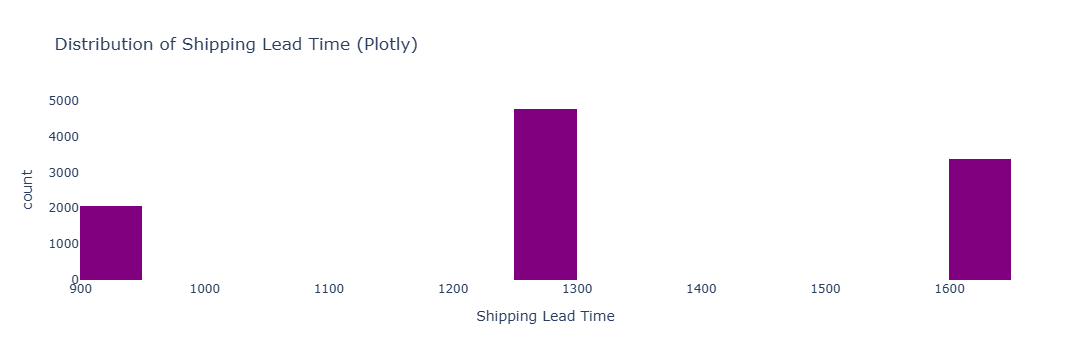

In [49]:
fig_hist = px.histogram(df, x='Shipping Lead Time', nbins=30,
                        title='Distribution of Shipping Lead Time (Plotly)',
                        color_discrete_sequence=['purple'])
fig_hist.update_layout(plot_bgcolor='rgba(0,0,0,0)', paper_bgcolor='rgba(0,0,0,0)')
fig_hist.show()

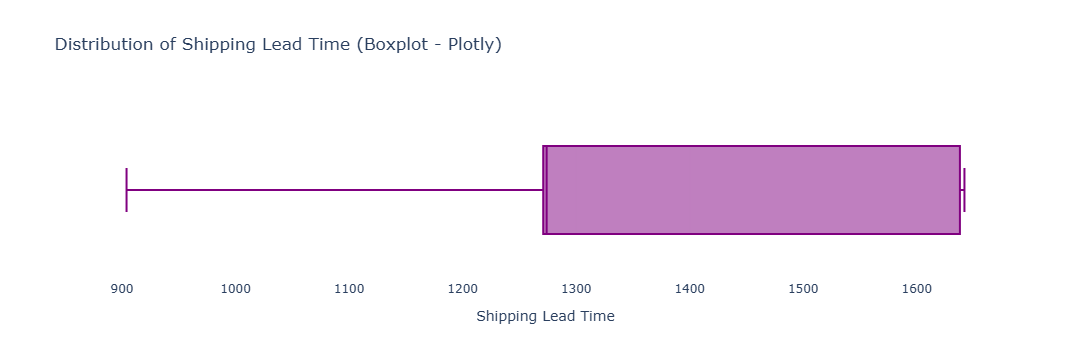

In [50]:
fig_box = px.box(df, x='Shipping Lead Time',
                 title='Distribution of Shipping Lead Time (Boxplot - Plotly)',
                 color_discrete_sequence=['purple'])
fig_box.update_layout(plot_bgcolor='rgba(0,0,0,0)', paper_bgcolor='rgba(0,0,0,0)')
fig_box.show()

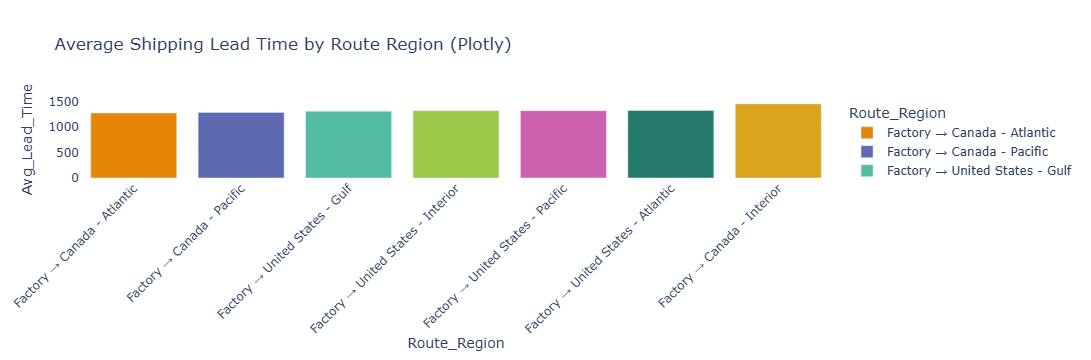

In [51]:
fig_rr_avg = px.bar(route_region_summary.sort_values(by='Avg_Lead_Time'),
                    x='Route_Region', y='Avg_Lead_Time',
                    title='Average Shipping Lead Time by Route Region (Plotly)',
                    color='Route_Region', color_discrete_sequence=px.colors.qualitative.Vivid)
fig_rr_avg.update_layout(xaxis_tickangle=-45, plot_bgcolor='rgba(0,0,0,0)', paper_bgcolor='rgba(0,0,0,0)')
fig_rr_avg.show()

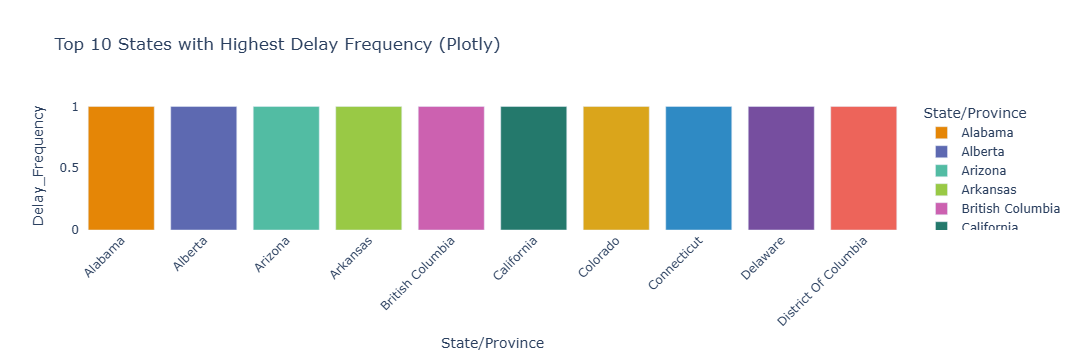

In [52]:
fig_delay = px.bar(congestion.head(10).reset_index(), x='State/Province', y='Delay_Frequency',
                   title='Top 10 States with Highest Delay Frequency (Plotly)',
                   color='State/Province', color_discrete_sequence=px.colors.qualitative.Vivid)
fig_delay.update_layout(xaxis_tickangle=-45, plot_bgcolor='rgba(0,0,0,0)', paper_bgcolor='rgba(0,0,0,0)')
fig_delay.show()

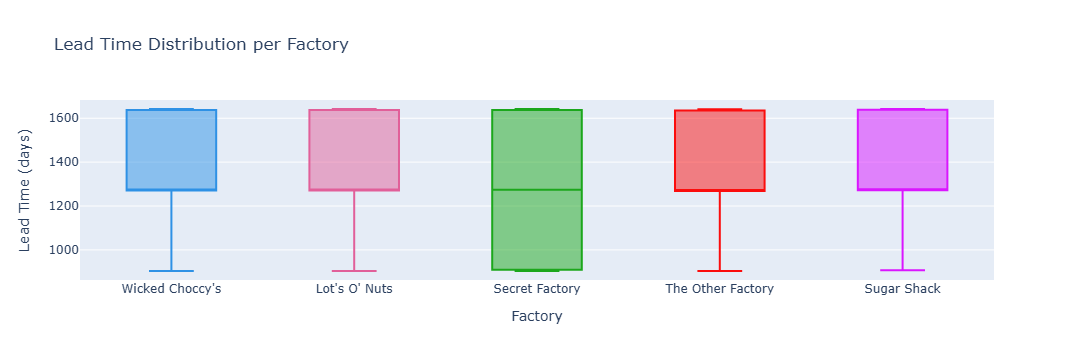

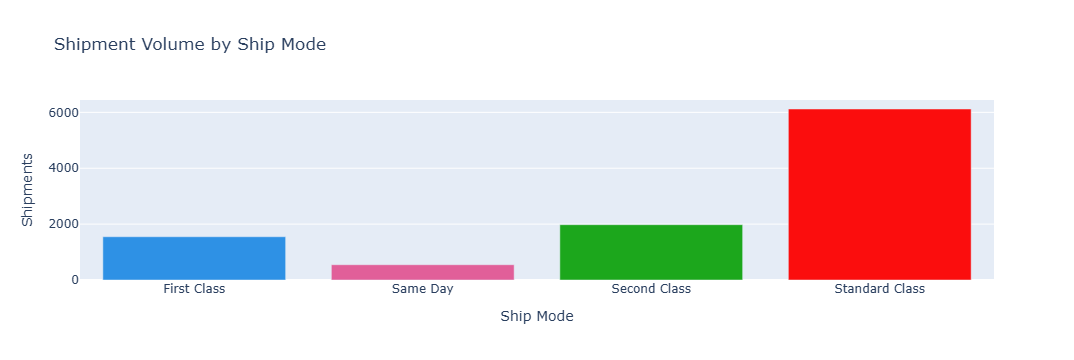

=== Top Bottleneck States ===
                Volume  Avg_Lead_Time
State/Province                       
California        2001    1318.427286
New York          1128    1324.493794
Texas              985    1310.305584
Pennsylvania       587    1324.199319
Washington         506    1360.662055
Illinois           492    1323.150407
Ohio               469    1325.733475
Florida            383    1311.396867
Michigan           255    1300.560784
North Carolina     249    1334.883534


In [53]:
# Visualizations
# Lead Time Distribution by Factory
fig_box = px.box(
    df, x="Factory", y="Shipping Lead Time", color="Factory",
    title="Lead Time Distribution per Factory",
    labels={"Shipping Lead Time": "Lead Time (days)"},
    color_discrete_sequence=px.colors.qualitative.Dark24
)
fig_box.update_layout(showlegend=False)
fig_box.show()

# Ship Mode Comparison
ship_mode_summary = df.groupby('Ship Mode').agg({
    'Shipping Lead Time': 'mean',
    'Ship Mode': 'count'
}).rename(columns={'Ship Mode': 'Shipments'}).reset_index()

fig_bar = px.bar(
    ship_mode_summary, x='Ship Mode', y='Shipments', color='Ship Mode',
    title='Shipment Volume by Ship Mode',
    color_discrete_sequence=px.colors.qualitative.Dark24
)
fig_bar.update_layout(showlegend=False)
fig_bar.show()

# Bottleneck States
volume = df.groupby('State/Province').size()
performance = df.groupby('State/Province')['Shipping Lead Time'].mean()
bottleneck_df = pd.DataFrame({
    'Volume': volume,
    'Avg_Lead_Time': performance
}).sort_values(by=['Volume', 'Avg_Lead_Time'], ascending=False).head(10)

print("=== Top Bottleneck States ===")
print(bottleneck_df)